# Capstone Two: Preprocessing and Training Data Development
## Retail demand forecasting for small businesses

**Author:** Jacob Paul  
**Input:** UCI Online Retail transaction workbook used by `02_exploratory_data_analysis.ipynb`  
**Output:** Leakage-aware product-week development data, train/validation/test splits, encoded and scaled feature matrices, and a reusable fitted preprocessor.

### Forecasting contract
At the start of each Monday, forecast total **fulfilled units sold per product during that Monday–Sunday week**, using information available through the preceding Sunday. This is a **rolling one-week-ahead** evaluation: after each week closes, its actual units may become history for the next forecast. It is **not** a seven-week forecast issued once at the start of the holdout. That task would require recursive or direct multi-horizon features instead.

The target is observed sales across all countries, not unconstrained demand: inventory availability and lost sales are unknown. No predictive model is fitted in this notebook.

### Rubric coverage

| Requirement | Implementation |
|---|---|
| Dummy/indicator features | Sparse one-hot encoding of product code and calendar month |
| Numeric standardization | Training-only median imputation and `StandardScaler` |
| Training and testing subsets | Date-based training, validation and final test partitions |
| Process and understanding | Feature availability, EDA changes, leakage checks and modeling handoff |
| Working notebook | Sequential code, saved outputs, checks and reproducible exports |


## 1. Setup and input discovery

Run from the repository root or its `notebooks/` directory. The source is `data/Online Retail.xlsx` (the current EDA location); `data/raw/Online Retail.xlsx` is also supported. No online download or absolute local path is required. Install dependencies with `python -m pip install -r requirements-preprocessing.txt` before starting Jupyter.

The split boundaries below are chosen from the calendar before examining holdout target values. Whole weeks stay together across every product.

In [1]:
from pathlib import Path
import calendar
import hashlib
import importlib.metadata
import json
import platform

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option('display.max_columns', 20)
plt.style.use('ggplot')

roots = [Path.cwd(), Path.cwd().parent]
REPO_ROOT = next((p for p in roots if (p / 'notebooks').is_dir() and (p / 'data').is_dir()), None)
if REPO_ROOT is None:
    raise FileNotFoundError('Run from the repository root or notebooks/ directory.')
DATA_PATH = next((p for p in [REPO_ROOT / 'data' / 'Online Retail.xlsx',
                            REPO_ROOT / 'data' / 'raw' / 'Online Retail.xlsx'] if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError('Place Online Retail.xlsx in data/ or data/raw/.')
OUTPUT_DIR = REPO_ROOT / 'data' / 'processed' / 'preprocessing_v1'
REPORT_DIR = REPO_ROOT / 'reports' / 'preprocessing'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

VALIDATION_START = pd.Timestamp('2011-08-29')
TEST_START = pd.Timestamp('2011-10-17')
MIN_PRIOR_SELLING_WEEKS = 4
MONTH_CATEGORIES = [f'{m:02d}' for m in range(1, 13)]
source_sha256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
versions = {p: importlib.metadata.version(p) for p in
            ['numpy', 'pandas', 'scipy', 'scikit-learn', 'matplotlib', 'openpyxl', 'joblib']}
print('Source:', DATA_PATH.relative_to(REPO_ROOT))
print('Python:', platform.python_version())
print('Package versions:', versions)

Source: data/Online Retail.xlsx
Python: 3.14.6
Package versions: {'numpy': '2.4.6', 'pandas': '3.0.3', 'scipy': '1.18.0', 'scikit-learn': '1.9.0', 'matplotlib': '3.11.0', 'openpyxl': '3.1.5', 'joblib': '1.5.3'}


## 2. Reproduce the current EDA cleaning rules

Follow the newer EDA, which supersedes the proposal's older suggestion to drop missing customer IDs. Retain valid fulfilled sales without `CustomerID`, as customer identity is not a predictor of aggregate product demand. Remove cancellation/adjustment invoices, non-positive quantities/prices, exact duplicates and non-merchandise stock codes without digits.

Do not estimate outlier thresholds from the full dataset. Keep valid bulk orders here; `StandardScaler` does not make heavy-tailed features Gaussian and is sensitive to extreme values. Training-only robust transformations may be compared during modeling. Do not scale or cap the target at this stage.

In [2]:
raw = pd.read_excel(DATA_PATH, engine='openpyxl')
required = ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
            'UnitPrice', 'CustomerID', 'Country']
assert set(required).issubset(raw.columns)
assert raw[['InvoiceNo', 'StockCode', 'Quantity', 'InvoiceDate', 'UnitPrice']].notna().all().all()
print(f'Raw rows: {len(raw):,}; date range: {raw.InvoiceDate.min()} to {raw.InvoiceDate.max()}')

df = raw.copy()
df['InvoiceNo'] = df['InvoiceNo'].astype(str).str.strip()
df['StockCode'] = df['StockCode'].astype(str).str.strip()
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='raise')
audit_rows = []
def audit_step(label, before, after):
    audit_rows.append({'step': label, 'rows_removed': before - after, 'rows_remaining': after})

before = len(df)
df = df.loc[~df.InvoiceNo.str.startswith(('C', 'A'))].copy()
audit_step('Remove cancellation/adjustment invoices', before, len(df))
before = len(df)
df = df.loc[df.Quantity > 0].copy()
audit_step('Keep positive quantities', before, len(df))
before = len(df)
df = df.loc[df.UnitPrice > 0].copy()
audit_step('Keep positive prices', before, len(df))
before = len(df)
df = df.drop_duplicates().copy()
audit_step('Remove exact duplicates', before, len(df))
before = len(df)
df = df.loc[df.StockCode.str.contains(r'\d', regex=True)].copy()
audit_step('Keep merchandise stock codes containing digits', before, len(df))
cleaning_audit = pd.DataFrame(audit_rows)
assert len(raw) - cleaning_audit.rows_removed.sum() == len(df)
print(cleaning_audit.to_string(index=False))
print(f'Missing customer IDs retained: {df.CustomerID.isna().sum():,}')
assert np.isfinite(df[['Quantity', 'UnitPrice']].to_numpy()).all()

Raw rows: 541,909; date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
                                          step  rows_removed  rows_remaining
       Remove cancellation/adjustment invoices          9291          532618
                      Keep positive quantities          1336          531282
                          Keep positive prices          1179          530103
                       Remove exact duplicates          5226          524877
Keep merchandise stock codes containing digits          2192          522685
Missing customer IDs retained: 131,402


## 3. Complete the weekly panel without future-dependent product selection

Weeks begin Monday. Drop the partial first and last calendar weeks using the dataset coverage boundaries. Aggregate all remaining positive merchandise sales to product-week units and weekly median price.

**Changes from the descriptive EDA:**

- Start a product at its first observed sale and extend it to the final complete dataset week. Do not stop at its eventual last sale; that date would not have been known at forecast time.
- A missing product-week after introduction means zero **recorded sales** under the assumption that the transaction extract is complete. It may reflect stockouts or discontinuation, not zero latent demand. Without an inventory/catalog feed, no end-of-life rule can be confirmed.
- Require four **previous** selling weeks for each forecast row. Do not select products using their total selling weeks across the full year.
- Price features use forward-filled historical prices, then a one-week shift. Never backfill from a future price.

The resulting row count will therefore differ from the EDA's retrospective lifetime panel.

In [3]:
df['WeekStart'] = df.InvoiceDate.dt.to_period('W-SUN').dt.start_time
first_boundary = raw.InvoiceDate.min().to_period('W-SUN').start_time
last_boundary = raw.InvoiceDate.max().to_period('W-SUN').start_time
full_weeks = pd.date_range(first_boundary + pd.Timedelta(weeks=1),
                           last_boundary - pd.Timedelta(weeks=1), freq='W-MON')
assert len(full_weeks) > 8
full_transactions = df.loc[df.WeekStart.isin(full_weeks)].copy()
weekly_observed = full_transactions.groupby(['StockCode', 'WeekStart'], as_index=False).agg(
    UnitsSold=('Quantity', 'sum'), MedianUnitPrice=('UnitPrice', 'median'))
first_seen = weekly_observed.groupby('StockCode').WeekStart.min()

# Products appear only after introduction; there are no pre-launch zero rows.
index = pd.MultiIndex.from_product([sorted(first_seen.index), full_weeks],
                                  names=['StockCode', 'WeekStart'])
panel = weekly_observed.set_index(['StockCode', 'WeekStart']).reindex(index).reset_index()
panel = panel.loc[panel.WeekStart >= panel.StockCode.map(first_seen)].copy()
panel['UnitsSold'] = panel.UnitsSold.fillna(0).astype(np.float64)
panel = panel.sort_values(['StockCode', 'WeekStart']).reset_index(drop=True)
assert not panel.duplicated(['StockCode', 'WeekStart']).any()
assert panel.groupby('StockCode').WeekStart.diff().dropna().eq(pd.Timedelta(weeks=1)).all()
assert panel.UnitsSold.sum() == full_transactions.Quantity.sum()
print('Complete weeks:', full_weeks.min().date(), 'to', full_weeks.max().date(), '| Count:', len(full_weeks))
print('Observed product-weeks:', len(weekly_observed), '| Completed panel rows:', len(panel))
print('Products introduced during coverage:', panel.StockCode.nunique())

Complete weeks: 2010-12-06 to 2011-11-28 | Count: 52
Observed product-weeks: 97063 | Completed panel rows: 173733
Products introduced during coverage: 3893


## 4. Engineer features available before the forecast week

Lag 1 is the prior **calendar week**, including a genuine zero when no sale was recorded. Rolling summaries use four completed prior weeks, not the current target. Eligibility requires both a four-calendar-week history and at least four earlier positive-sales weeks. A week with no sales remains valid after the product becomes eligible.

`Month` is a calendar category known in advance. Product codes are categorical identifiers, not ordered numbers. Calendar sine/cosine features provide a smooth seasonal representation, but one year of history is insufficient to establish reliable annual seasonality.

In [4]:
NUMERIC_FEATURES = [
    'UnitsLag1', 'UnitsLag2', 'UnitsLag4', 'RollingMean4', 'RollingStd4',
    'ZeroWeeksLast4', 'WeeksSinceFirstSale', 'PriorSellingWeeks',
    'LastObservedUnitPrice', 'WeekSin', 'WeekCos'
]
CATEGORICAL_FEATURES = ['StockCode', 'Month']
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = 'UnitsSold'


def add_history_features(weekly):
    out = weekly.sort_values(['StockCode', 'WeekStart']).copy()
    g = out.groupby('StockCode', sort=False)['UnitsSold']
    for lag in [1, 2, 4]:
        out[f'UnitsLag{lag}'] = g.shift(lag)
    out['RollingMean4'] = g.transform(lambda s: s.shift(1).rolling(4, min_periods=4).mean())
    # Recompute each four-week window directly: incremental rolling variance can
    # leave a small positive residual for an all-zero/constant window.
    out['RollingStd4'] = g.transform(
        lambda s: s.shift(1).rolling(4, min_periods=4).apply(
            lambda values: np.std(values, ddof=0), raw=True))
    out['ZeroWeeksLast4'] = g.transform(lambda s: s.eq(0).astype(float).shift(1).rolling(4, min_periods=4).sum())
    out['PriorSellingWeeks'] = g.transform(lambda s: s.gt(0).cumsum().shift(1, fill_value=0)).astype(int)
    starts = out.groupby('StockCode').WeekStart.transform('min')
    out['WeeksSinceFirstSale'] = ((out.WeekStart - starts).dt.days // 7).astype(int)
    out['LastObservedUnitPrice'] = out.groupby('StockCode')['MedianUnitPrice'].transform(lambda s: s.ffill().shift(1))
    out['Month'] = out.WeekStart.dt.month.map(lambda m: f'{m:02d}').astype(object)
    iso_week = out.WeekStart.dt.isocalendar().week.astype(float)
    out['WeekSin'] = np.sin(2 * np.pi * iso_week / 52.1775)
    out['WeekCos'] = np.cos(2 * np.pi * iso_week / 52.1775)
    out['Eligible'] = (out.WeeksSinceFirstSale >= 4) & (out.PriorSellingWeeks >= MIN_PRIOR_SELLING_WEEKS)
    return out

featured = add_history_features(panel)
development = featured.loc[featured.Eligible, ['StockCode', 'WeekStart', TARGET] +
                            [c for c in FEATURES if c != 'StockCode']].copy()
development = development.sort_values(['WeekStart', 'StockCode']).reset_index(drop=True)
development['RowID'] = development.StockCode + '|' + development.WeekStart.dt.strftime('%Y-%m-%d')
assert development.RowID.is_unique
assert development[NUMERIC_FEATURES].notna().all().all()
assert (development[TARGET] >= 0).all()
print('Eligible development rows:', len(development), '| Products:', development.StockCode.nunique())
print('Warm-up/ineligible rows excluded:', len(featured) - len(development))
# Show historical training examples, not final-test target patterns.
development.loc[development.WeekStart < VALIDATION_START,
                ['StockCode', 'WeekStart', TARGET, 'UnitsLag1', 'RollingMean4', 'PriorSellingWeeks']].head(8)

Eligible development rows: 128794 | Products: 3434
Warm-up/ineligible rows excluded: 44939


,StockCode,WeekStart,UnitsSold,UnitsLag1,RollingMean4,PriorSellingWeeks
0,10002,2011-01-10,42.0,73.0,29.00,4
1,10125,2011-01-10,79.0,98.0,51.75,4
2,10133,2011-01-10,67.0,11.0,26.75,4
3,10135,2011-01-10,116.0,225.0,146.25,4
4,11001,2011-01-10,1.0,32.0,13.00,4
5,15034,2011-01-10,5.0,169.0,46.25,4
6,15036,2011-01-10,159.0,18.0,20.75,4
7,15056BL,2011-01-10,19.0,95.0,45.75,4


## 5. Feature decisions and rubric questions

**Does this dataset have categorical data?** Yes: `StockCode`, `Country`, `Description`, `CustomerID` and invoice identifiers are categorical or identifier-like. Only product code and forecast month are encoded in this baseline. Country is not a row-level attribute after pooling warehouse-level demand across markets; using the current week's country mix would leak sales outcomes. Product descriptions and customer IDs are unnecessary here. Every forecast week begins Monday, so day of week is constant and adds no information.

**Do features use different ranges?** Yes: historical units and prices can be large, counts/lifecycle values vary by weeks, and sine/cosine values lie in [−1,1]. Standardize numeric features using the training mean and standard deviation. Leave one-hot indicators as 0/1. This is standardization, not row-wise L2 normalization or a promise that every feature lies in [0,1].

Same-week price, revenue, transaction count and `IsZeroDemand` are excluded: they depend on outcomes within the week being predicted. Keep the target in original units for interpretable future error metrics. No holiday flag is invented without a verified calendar; it can be added later as a known-in-advance feature.

In [5]:
feature_dictionary = pd.DataFrame([
    ('UnitsLag1 / UnitsLag2 / UnitsLag4', 'Numeric', 'Observed units 1, 2, 4 calendar weeks earlier', 'StandardScaler'),
    ('RollingMean4 / RollingStd4', 'Numeric', 'Demand summaries over the previous four weeks', 'StandardScaler'),
    ('ZeroWeeksLast4', 'Numeric count', 'Zero-sales weeks among the previous four', 'StandardScaler'),
    ('WeeksSinceFirstSale', 'Numeric count', 'Product age in weeks at forecast origin', 'StandardScaler'),
    ('PriorSellingWeeks', 'Numeric count', 'Positive-sales weeks strictly before forecast origin', 'StandardScaler'),
    ('LastObservedUnitPrice', 'Numeric', 'Last available historical weekly median price', 'StandardScaler'),
    ('WeekSin / WeekCos', 'Numeric', 'Known calendar of the forecast week', 'StandardScaler'),
    ('StockCode', 'Categorical', 'Product identity already observed in prior sales', 'One-hot; vocabulary learned on training rows'),
    ('Month', 'Categorical', 'Known forecast month', 'One-hot; fixed calendar domain 01–12'),
], columns=['feature', 'type', 'availability', 'processing'])
print(feature_dictionary.to_string(index=False))
assert TARGET not in FEATURES
assert not set(['Revenue', 'Transactions', 'MedianUnitPrice', 'CustomerID', 'Description', 'IsZeroDemand']).intersection(FEATURES)

                          feature          type                                         availability                                   processing
UnitsLag1 / UnitsLag2 / UnitsLag4       Numeric        Observed units 1, 2, 4 calendar weeks earlier                               StandardScaler
       RollingMean4 / RollingStd4       Numeric        Demand summaries over the previous four weeks                               StandardScaler
                   ZeroWeeksLast4 Numeric count             Zero-sales weeks among the previous four                               StandardScaler
              WeeksSinceFirstSale Numeric count              Product age in weeks at forecast origin                               StandardScaler
                PriorSellingWeeks Numeric count Positive-sales weeks strictly before forecast origin                               StandardScaler
            LastObservedUnitPrice       Numeric        Last available historical weekly median price                        

## 6. Split by forecast date before fitting any transformation

- **Training:** eligible weeks before 29 August 2011.
- **Validation:** 29 August through 10 October 2011 (week-start dates).
- **Final test:** 17 October through 28 November 2011 (week-start dates).

This reserves two seven-week blocks and places the test period in the autumn/Q4 regime. Do not shuffle rows or split different products from the same week across partitions. Validation supports model selection; the final test remains reserved for final evaluation. No test target plots or model comparisons are performed here.

Historical actuals from an earlier validation/test week may inform later lag features under the stated rolling one-week-ahead contract. They never fit the scaler, encoder or a predictive model in this notebook.

     split first_week  last_week  weeks  rows  products
     train 2011-01-10 2011-08-22     33 83092      3084
validation 2011-08-29 2011-10-10      7 22191      3239
      test 2011-10-17 2011-11-28      7 23511      3434


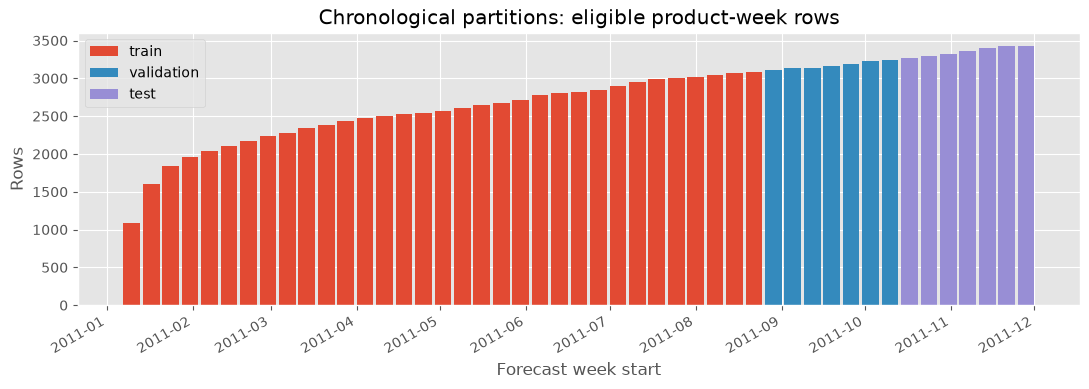

In [6]:
development['Split'] = np.select(
    [development.WeekStart < VALIDATION_START, development.WeekStart < TEST_START],
    ['train', 'validation'], default='test')
split_frames = {name: development.loc[development.Split.eq(name)].reset_index(drop=True)
                for name in ['train', 'validation', 'test']}
assert all(len(frame) > 0 for frame in split_frames.values())
assert split_frames['train'].WeekStart.max() < split_frames['validation'].WeekStart.min()
assert split_frames['validation'].WeekStart.max() < split_frames['test'].WeekStart.min()
assert development.groupby('WeekStart').Split.nunique().eq(1).all()
assert sum(len(frame) for frame in split_frames.values()) == len(development)

split_summary = pd.DataFrame([
    {'split': name, 'first_week': frame.WeekStart.min().date().isoformat(),
     'last_week': frame.WeekStart.max().date().isoformat(),
     'weeks': frame.WeekStart.nunique(), 'rows': len(frame), 'products': frame.StockCode.nunique()}
    for name, frame in split_frames.items()])
print(split_summary.to_string(index=False))
X_raw = {name: frame[FEATURES].copy() for name, frame in split_frames.items()}
y = {name: frame[TARGET].to_numpy(dtype=np.float64) for name, frame in split_frames.items()}

fig, ax = plt.subplots(figsize=(11, 4))
for name, frame in split_frames.items():
    counts = frame.groupby('WeekStart').size()
    ax.bar(counts.index, counts.values, width=6, label=name)
ax.set(title='Chronological partitions: eligible product-week rows', xlabel='Forecast week start', ylabel='Rows')
ax.legend(); fig.autofmt_xdate(); plt.tight_layout(); plt.show()

## 7. Encode categories and standardize numeric features

`OneHotEncoder` creates the same kind of indicator features as `get_dummies()`, while retaining an explicit training vocabulary and handling previously unseen product codes. Product IDs are stored in a sparse matrix to avoid allocating thousands of dense indicator columns.

The numeric pipeline learns imputation medians and scaling statistics from training rows only. Eligibility removes initial lag gaps, so no numeric values currently require imputation; the median step is a safeguard for future inputs. Zero sales and zero lags are valid values and are never replaced as missing.

All 12 month categories are specified from calendar knowledge, not discovered from validation/test data. Some autumn months have no eligible training rows, so those indicator columns are constant during training and provide no learned seasonal effect by themselves. This calendar extrapolation is a limitation of the short history. Unseen product codes receive an all-zero product block; historical-demand features remain available.

In [7]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
preprocessor_template = ColumnTransformer([
    ('numeric', numeric_pipeline, NUMERIC_FEATURES),
    ('product', OneHotEncoder(handle_unknown='ignore', sparse_output=True, dtype=np.float64), ['StockCode']),
    ('calendar', OneHotEncoder(categories=[MONTH_CATEGORIES], handle_unknown='ignore',
                              sparse_output=True, dtype=np.float64), ['Month'])
], remainder='drop', sparse_threshold=1.0, verbose_feature_names_out=True)

preprocessor = clone(preprocessor_template)
X_processed = {'train': sparse.csr_matrix(preprocessor.fit_transform(X_raw['train']))}
for name in ['validation', 'test']:
    X_processed[name] = sparse.csr_matrix(preprocessor.transform(X_raw[name]))
feature_names = preprocessor.get_feature_names_out().tolist()
assert len(feature_names) == len(set(feature_names))
for name, matrix in X_processed.items():
    assert matrix.shape == (len(split_frames[name]), len(feature_names))
    assert np.isfinite(matrix.data).all()
    memory_mb = (matrix.data.nbytes + matrix.indices.nbytes + matrix.indptr.nbytes) / 1024**2
    print(f'{name}: shape={matrix.shape}, nonzeros={matrix.nnz:,}, CSR memory={memory_mb:.2f} MiB')
print('Numeric features:', len(NUMERIC_FEATURES))
print('Product dummy columns:', len(preprocessor.named_transformers_['product'].categories_[0]))
print('Calendar dummy columns:', len(MONTH_CATEGORIES))
print('First feature names:', feature_names[:15])

train: shape=(83092, 3107), nonzeros=1,080,196, CSR memory=12.68 MiB
validation: shape=(22191, 3107), nonzeros=287,880, CSR memory=3.38 MiB
test: shape=(23511, 3107), nonzeros=303,720, CSR memory=3.57 MiB
Numeric features: 11
Product dummy columns: 3084
Calendar dummy columns: 12
First feature names: ['numeric__UnitsLag1', 'numeric__UnitsLag2', 'numeric__UnitsLag4', 'numeric__RollingMean4', 'numeric__RollingStd4', 'numeric__ZeroWeeksLast4', 'numeric__WeeksSinceFirstSale', 'numeric__PriorSellingWeeks', 'numeric__LastObservedUnitPrice', 'numeric__WeekSin', 'numeric__WeekCos', 'product__StockCode_10002', 'product__StockCode_10080', 'product__StockCode_10120', 'product__StockCode_10124A']


                       raw_min    raw_max  raw_mean  raw_sample_std  scaled_mean  scaled_population_std
UnitsLag1               0.0000  4562.0000   31.5914         98.4637         -0.0                    1.0
UnitsLag2               0.0000  4562.0000   30.9937         97.6710         -0.0                    1.0
UnitsLag4               0.0000  4562.0000   30.8705         97.0811          0.0                    1.0
RollingMean4            0.0000  1995.7500   31.0455         74.5028          0.0                    1.0
RollingStd4             0.0000  1776.8062   21.9590         59.1305         -0.0                    1.0
ZeroWeeksLast4          0.0000     4.0000    1.3983          1.4247          0.0                    1.0
WeeksSinceFirstSale     4.0000    37.0000   21.2345          9.2439          0.0                    1.0
PriorSellingWeeks       4.0000    36.0000   13.7302          8.2133          0.0                    1.0
LastObservedUnitPrice   0.0400   295.0000    3.6593          7.7

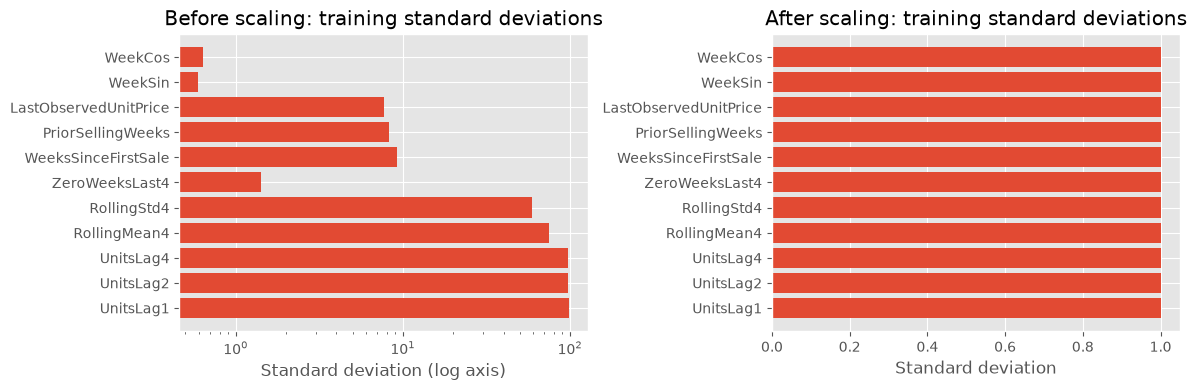

     split  unknown_product_rows  unknown_products months_absent_from_training
     train                     0                 0                            
validation                   603               155                       09,10
      test                  1923               350                       10,11
Validation/test transformed means need not equal zero: their distribution can change.


In [8]:
fitted_numeric = preprocessor.named_transformers_['numeric']
train_numeric = fitted_numeric.transform(X_raw['train'][NUMERIC_FEATURES])
scaler = fitted_numeric.named_steps['scaler']
scaling_audit = X_raw['train'][NUMERIC_FEATURES].agg(['min', 'max', 'mean', 'std']).T
scaling_audit.columns = ['raw_min', 'raw_max', 'raw_mean', 'raw_sample_std']
scaling_audit['scaled_mean'] = train_numeric.mean(axis=0)
scaling_audit['scaled_population_std'] = train_numeric.std(axis=0, ddof=0)
print(scaling_audit.round(4).to_string())
np.testing.assert_allclose(scaler.mean_, X_raw['train'][NUMERIC_FEATURES].mean().to_numpy(), atol=1e-9)
np.testing.assert_allclose(scaler.n_samples_seen_, len(X_raw['train']))
np.testing.assert_allclose(train_numeric.mean(axis=0), 0, atol=1e-9)
nonconstant = scaler.var_ > 1e-12
np.testing.assert_allclose(train_numeric[:, nonconstant].std(axis=0, ddof=0), 1, atol=1e-9)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
raw_stds = X_raw['train'][NUMERIC_FEATURES].std(ddof=0)
axes[0].barh(NUMERIC_FEATURES, raw_stds)
axes[0].set_xscale('log')
axes[0].set(title='Before scaling: training standard deviations', xlabel='Standard deviation (log axis)')
axes[1].barh(NUMERIC_FEATURES, train_numeric.std(axis=0, ddof=0))
axes[1].set(title='After scaling: training standard deviations', xlabel='Standard deviation')
plt.tight_layout(); plt.show()

product_encoder = preprocessor.named_transformers_['product']
known_products = set(product_encoder.categories_[0])
unknown_summary = []
for name, frame in split_frames.items():
    unknown = ~frame.StockCode.isin(known_products)
    absent_training_months = sorted(set(frame.Month) - set(X_raw['train'].Month))
    unknown_summary.append({'split':name, 'unknown_product_rows':int(unknown.sum()),
                            'unknown_products':frame.loc[unknown, 'StockCode'].nunique(),
                            'months_absent_from_training':','.join(absent_training_months)})
unknown_summary = pd.DataFrame(unknown_summary)
print(unknown_summary.to_string(index=False))
print('Validation/test transformed means need not equal zero: their distribution can change.')

## 8. Leakage and alignment checks

The following checks go beyond a successful run: they verify chronological separation, train-only transformation state, row/target alignment, manual lag arithmetic, unknown-category handling, and invariance to changing current/future outcomes. The future-perturbation check changes units and prices on and after a cutoff and confirms that features and eligibility up to that cutoff do not change.

In [9]:
checks = []
def record_check(name, condition):
    assert bool(condition), name
    checks.append({'check':name, 'result':'PASS'})

record_check('Unique product-week key', not development.duplicated(['StockCode','WeekStart']).any())
record_check('Disjoint split RowIDs', len(set().union(*(set(f.RowID) for f in split_frames.values()))) == len(development))
record_check('One partition per calendar week', development.groupby('WeekStart').Split.nunique().eq(1).all())
record_check('Training precedes validation precedes test',
    split_frames['train'].WeekStart.max() < split_frames['validation'].WeekStart.min()
    and split_frames['validation'].WeekStart.max() < split_frames['test'].WeekStart.min())
record_check('Target excluded from predictor columns', TARGET not in FEATURES)
record_check('Every forecast has four previous selling weeks', development.PriorSellingWeeks.ge(4).all())
record_check('Scaler fit sees only training rows', int(scaler.n_samples_seen_) == len(X_raw['train']))
record_check('Product vocabulary equals training products', known_products == set(X_raw['train'].StockCode))
record_check('Finite matrices with matching schemas', all(np.isfinite(m.data).all() and m.shape[1] == len(feature_names) for m in X_processed.values()))
record_check('Targets and row keys align', all(len(y[name]) == X_processed[name].shape[0] == len(frame) for name,frame in split_frames.items()))

sample = split_frames['train'].sample(n=30, random_state=42)
lookup = panel.set_index(['StockCode','WeekStart']).UnitsSold
for _, row in sample.iterrows():
    past = np.array([lookup.loc[(row.StockCode, row.WeekStart - pd.Timedelta(weeks=j))] for j in range(1,5)])
    np.testing.assert_allclose([row.UnitsLag1,row.UnitsLag2,row.UnitsLag4,row.RollingMean4,row.RollingStd4],
                               [past[0],past[1],past[3],past.mean(),past.std(ddof=0)],
                               rtol=1e-10, atol=1e-10)
record_check('Sample lags and rolling statistics match prior calendar weeks', True)

# Verify every complete window, including constant/zero histories after large sales.
history_matrix = np.column_stack([
    featured.groupby('StockCode', sort=False).UnitsSold.shift(j).to_numpy(dtype=float)
    for j in range(1, 5)
])
complete_history = np.isfinite(history_matrix).all(axis=1)
expected_std = np.std(history_matrix[complete_history], axis=1, ddof=0)
actual_std = featured.loc[complete_history, 'RollingStd4'].to_numpy()
np.testing.assert_allclose(actual_std, expected_std, rtol=1e-10, atol=1e-10)
constant_history = np.ptp(history_matrix[complete_history], axis=1) == 0
assert (actual_std[constant_history] == 0).all()
record_check('All complete rolling standard deviations match direct calculation; constant windows equal zero', True)

mutated = panel.copy()
mask = mutated.WeekStart.ge(VALIDATION_START)
mutated.loc[mask,'UnitsSold'] = mutated.loc[mask,'UnitsSold'] + 100000
mutated.loc[mask,'MedianUnitPrice'] = 999999
mutated_features = add_history_features(mutated)
compare_cols = FEATURES + ['Eligible']
original_past = featured.loc[featured.WeekStart.le(VALIDATION_START), compare_cols].reset_index(drop=True)
mutated_past = mutated_features.loc[mutated_features.WeekStart.le(VALIDATION_START), compare_cols].reset_index(drop=True)
pd.testing.assert_frame_equal(original_past, mutated_past)
record_check('Current/future outcome changes cannot alter earlier features', True)
del mutated, mutated_features, original_past, mutated_past

probe = X_raw['validation'].head(1).copy()
probe.loc[:, 'StockCode'] = '__UNSEEN_PRODUCT_CHECK__'
probe_matrix = sparse.csr_matrix(preprocessor.transform(probe))
record_check('Unseen product transforms without failure', probe_matrix.shape[1] == len(feature_names) and np.isfinite(probe_matrix.data).all())
record_check('Unseen product has all-zero product indicator block', product_encoder.transform(probe[['StockCode']]).nnz == 0)
check_report = pd.DataFrame(checks)
print(check_report.to_string(index=False))

                                                                                         check result
                                                                       Unique product-week key   PASS
                                                                         Disjoint split RowIDs   PASS
                                                               One partition per calendar week   PASS
                                                    Training precedes validation precedes test   PASS
                                                        Target excluded from predictor columns   PASS
                                                Every forecast has four previous selling weeks   PASS
                                                            Scaler fit sees only training rows   PASS
                                                   Product vocabulary equals training products   PASS
                                                         Finite matrices with matc

## 9. Prepare week-based cross-validation for the modeling stage

Applying `TimeSeriesSplit` directly to stacked product-week rows can put different products from the same week into training and validation. Instead, split **unique training weeks**, then map those dates to row positions. The next cell creates three expanding-window folds with four-week validation blocks, wholly inside the training partition.

During hyperparameter tuning, use the **raw feature frame** with `Pipeline([('preprocess', clone(preprocessor_template)), ('model', estimator)])` and these row indices. That fits each fold's encoder, imputer and scaler only on its own training weeks. Do not cross-validate the already-transformed full-training matrix. Per-row eligibility and shifted history remain valid for the stated rolling one-week-ahead setup.

In [10]:
def make_week_cv_splits(training_frame, n_splits=3, test_size_weeks=4):
    weeks = np.sort(training_frame.WeekStart.unique())
    splitter = TimeSeriesSplit(n_splits=n_splits, test_size=test_size_weeks)
    folds, rows = [], []
    for fold, (a, b) in enumerate(splitter.split(weeks), start=1):
        train_rows = np.flatnonzero(training_frame.WeekStart.isin(weeks[a]).to_numpy())
        valid_rows = np.flatnonzero(training_frame.WeekStart.isin(weeks[b]).to_numpy())
        assert training_frame.iloc[train_rows].WeekStart.max() < training_frame.iloc[valid_rows].WeekStart.min()
        folds.append((train_rows, valid_rows))
        rows.append({'fold':fold, 'train_first_week':str(pd.Timestamp(weeks[a[0]]).date()),
                     'train_last_week':str(pd.Timestamp(weeks[a[-1]]).date()),
                     'validation_first_week':str(pd.Timestamp(weeks[b[0]]).date()),
                     'validation_last_week':str(pd.Timestamp(weeks[b[-1]]).date()),
                     'train_rows':len(train_rows), 'validation_rows':len(valid_rows)})
    return folds, pd.DataFrame(rows)

cv_splits, cv_summary = make_week_cv_splits(split_frames['train'])
print(cv_summary.to_string(index=False))

 fold train_first_week train_last_week validation_first_week validation_last_week  train_rows  validation_rows
    1       2011-01-10      2011-05-30            2011-06-06           2011-06-27       47765            11255
    2       2011-01-10      2011-06-27            2011-07-04           2011-07-25       59020            11852
    3       2011-01-10      2011-07-25            2011-08-01           2011-08-22       70872            12220


## 10. Save reusable modeling artifacts

The compressed development CSV preserves the unscaled predictors, target, date, row key and split label. Use it for fold-specific preprocessing later. Sparse `.npz` matrices and `.npy` targets are convenient for a single fixed train/validation/test experiment. Metadata files preserve row alignment. Keep matrices sparse rather than calling `.toarray()` on the full product-dummy matrix.

The fitted `preprocessor.joblib` is for transforming future raw feature rows with the training vocabulary and scaling parameters. Recreate temporal features before using it; the transformer does not build lag history. Only load a joblib artifact you created or trust, and use matching package versions.

Outputs are written to `data/processed/preprocessing_v1/`. Regenerating this notebook replaces this stage's outputs. Small audit reports are kept in `reports/preprocessing/`; large generated data are excluded from Git via `.gitignore`.

In [11]:
development.to_csv(OUTPUT_DIR / 'development_dataset.csv.gz', index=False, compression='gzip')
for name, frame in split_frames.items():
    sparse.save_npz(OUTPUT_DIR / f'X_{name}.npz', X_processed[name], compressed=True)
    np.save(OUTPUT_DIR / f'y_{name}.npy', y[name], allow_pickle=False)
    frame[['RowID','StockCode','WeekStart']].to_csv(OUTPUT_DIR / f'rows_{name}.csv.gz', index=False, compression='gzip')
joblib.dump(preprocessor, OUTPUT_DIR / 'preprocessor.joblib', compress=3)
(OUTPUT_DIR / 'feature_names.json').write_text(json.dumps(feature_names, indent=2))
manifest = {
    'stage':'preprocessing_v1', 'forecast_horizon':'rolling one-week ahead',
    'target':TARGET, 'source_file':str(DATA_PATH.relative_to(REPO_ROOT)),
    'source_sha256':source_sha256, 'python':platform.python_version(), 'packages':versions,
    'validation_start':str(VALIDATION_START.date()), 'test_start':str(TEST_START.date()),
    'minimum_prior_selling_weeks':MIN_PRIOR_SELLING_WEEKS,
    'numeric_features':NUMERIC_FEATURES, 'categorical_features':CATEGORICAL_FEATURES,
    'encoded_feature_count':len(feature_names),
    'splits':split_summary.to_dict(orient='records'),
    'checks_passed':len(check_report), 'row_order':'WeekStart then StockCode within each split',
    'panel_assumption':'all introduced products remain at risk through final complete week; no inventory status available',
}
(OUTPUT_DIR / 'manifest.json').write_text(json.dumps(manifest, indent=2))
(REPORT_DIR / 'manifest.json').write_text(json.dumps(manifest, indent=2))
for name, table in {
    'cleaning_audit':cleaning_audit, 'split_summary':split_summary,
    'feature_dictionary':feature_dictionary, 'validation_checks':check_report,
    'unknown_categories':unknown_summary, 'cv_folds':cv_summary
}.items():
    table.to_csv(REPORT_DIR / f'{name}.csv', index=False)
scaling_audit.to_csv(REPORT_DIR / 'scaling_audit.csv', index_label='feature')

# Verify that the saved matrix, target, metadata and preprocessor round-trip correctly.
reloaded_preprocessor = joblib.load(OUTPUT_DIR / 'preprocessor.joblib')
probe_expected = X_processed['validation'][:5]
probe_reloaded = sparse.csr_matrix(reloaded_preprocessor.transform(X_raw['validation'].head(5)))
np.testing.assert_allclose((probe_expected - probe_reloaded).toarray(), 0, atol=1e-12)
for name, frame in split_frames.items():
    restored = sparse.load_npz(OUTPUT_DIR / f'X_{name}.npz')
    assert restored.shape == X_processed[name].shape
    difference = restored - X_processed[name]
    assert difference.nnz == 0
    np.testing.assert_array_equal(np.load(OUTPUT_DIR / f'y_{name}.npy', allow_pickle=False), y[name])
    rows = pd.read_csv(OUTPUT_DIR / f'rows_{name}.csv.gz', dtype={'StockCode':str})
    assert rows.RowID.tolist() == frame.RowID.tolist()
print('All exported matrices, targets, row keys and transformer passed reload checks.')
print('Artifacts:', OUTPUT_DIR.relative_to(REPO_ROOT))
print('Audit reports:', REPORT_DIR.relative_to(REPO_ROOT))
print(f'Total artifact size: {sum(f.stat().st_size for f in OUTPUT_DIR.iterdir()) / 1024**2:.2f} MiB')

All exported matrices, targets, row keys and transformer passed reload checks.
Artifacts: data/processed/preprocessing_v1
Audit reports: reports/preprocessing
Total artifact size: 7.55 MiB


## 11. Summary and modeling handoff

The completed development dataset contains **128,794 product-week rows across 3,434 products**. The 522,685 valid merchandise transaction rows match the current EDA cleaning result. After complete-week restriction and prior-only eligibility, training begins on 10 January 2011.

| Split | Forecast week starts | Weeks | Rows |
|---|---|---:|---:|
| Training | 2011-01-10 to 2011-08-22 | 33 | 83,092 |
| Validation | 2011-08-29 to 2011-10-10 | 7 | 22,191 |
| Final test | 2011-10-17 to 2011-11-28 | 7 | 23,511 |

There are **3,107 processed features**: 11 standardized numeric columns, 3,084 training-product indicators and 12 fixed calendar-month indicators. Validation contains 603 rows from 155 products absent from the training vocabulary; test contains 1,923 rows from 350 such products. Unknown products transform safely but require separate evaluation later.

All **15 leakage/alignment checks** passed, as did the matrix, target, metadata and transformer reload checks. All 11 code cells were executed sequentially twice, each in a fresh Python process, with outputs saved. A Jupyter kernel could not run here because communication sockets are blocked. The user’s macOS/Python 3.14 environment was not reproduced. Rolling standard deviations are recomputed directly per window, and every complete window is independently checked, including exact zeros for constant histories.

The rubric is addressed through categorical indicators, numeric standardization, chronological training/testing subsets, and an additional validation set. The notebook explicitly fits all learned preprocessing on training rows only and preserves target units.

For the next modeling stage:

1. Start with last-week demand, a prior-four-week mean, and a training-only historical-product mean as naive baselines.
2. Fit candidate regression models using week-based cross-validation on the raw training frame and a pipeline. The scaled matrix supports linear/distance-based models; tree models generally do not require scaling, but all candidates must follow the same temporal split.
3. Use validation to select the model and settings, then lock choices. If refitting on train+validation, refit preprocessing on that combined past dataset only; never include test rows in a fit.
4. Evaluate once on the final test under the rolling one-week-ahead contract. Report MAE, RMSE, bias, zero-sales performance and seen/unseen-product performance. Do not report prediction accuracy at this preprocessing stage.

**Limits:** only one annual cycle; no inventory/discontinuation data; observed sales rather than latent demand; unobserved promotion/exposure; changing product identities; missing product taxonomy; bulk sales and cancellation treatment inherited from EDA. Autumn month indicators may be unseen in training, and historical feature values can drift. These are proof-of-concept data, not evidence of a deployed forecasting system.

### Sources

- Project EDA: `notebooks/02_exploratory_data_analysis.ipynb` in this repository (the demand-focused cleaning rules).
- Chen, D. (2015). [Online Retail dataset, UCI](https://doi.org/10.24432/C5BW33), CC BY 4.0.
- [scikit-learn preprocessing](https://scikit-learn.org/stable/modules/preprocessing.html).
- [scikit-learn common pitfalls: data leakage](https://scikit-learn.org/stable/common_pitfalls.html).
- Springboard Capstone Two preprocessing instructions and rubric supplied with the assignment.

Prepared with AI assistance; review and discuss the assumptions with your mentor.
